In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd                    # pandas is the "python data analysis package"
import os                              # operating system services
from scipy.optimize import curve_fit   # non-linear curve fitting

np.random.seed(0)                      # set the random seed for reproducibility

Learning From Data
==================

The goal of this project is to learn how to use data to make inferences from data. There is a most excellent tool for this in the scipy library called `curve_fit`, but before we jump to that relatively sophisticated tool, I'd like to frame the problem a bit differently first. 

Linear Regression
-----------------

Suppose I have a system that produces an output $y$ from an input $x$. I may have an expectation that the output should be a superposition of two terms: (a) a term that is a constant independent of $x$, and (b) a second term that is proportional to $x$, but I don't know the coefficient of proportionality. So I can think of the system like so:

$$ y = A + B x $$

Now, further suppse that I have two examples of $x$ and $y$: ($x_1$, $x_2$), and ($y_1$, $y_2$). Since I have two unknowns I could write this as two equations:

$$
\begin{align}
y_1 & = A + B x_1\\
y_2 & = A + B x_2
\end{align}
$$

And then solve for $A$ and $B$. But notice I could also write the $x$ and $y$ values as vectors and form a matrix equation like so:

$$ \begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} 1 &  x_1 \\ 1 & x_2 \end{bmatrix} \begin{bmatrix} A \\ B \end{bmatrix} $$

The $y$ vector is the data. The matrix with the columns of ones and $x$ values describes the expected functions in the superposition, let's call it the "model" matrix. The coefficients are sometimes called the "parameters" of the model. Then I could use the matrix inverse, or Gaussian elimination, or LU decomposition to solve for $A$ and $B$. This will give me values of $A$ and $B$ that "go through" the two data points *exactly*. However, what happens if I have three data points? Or four? Then I'd get a matrix something like this:

$$ \begin{bmatrix} y_1 \\ y_2 \\ y_3 \\ y_4 \end{bmatrix} = \begin{bmatrix} 1 &  x_1 \\ 1 & x_2 \\ 1 & x_3 \\ 1 & x_4\end{bmatrix} \begin{bmatrix} A \\ B \end{bmatrix} $$

or we might think of this as:

$$ \vec{y} = \overline{M} \vec{\alpha} $$

Now there is no unique solution in general. We'll need a different approach. One idea is to use the SVD factorization that we discussed in project 6 to factorize the model matrix, so:

$$ \overline{M} = (\overline{U})(\overline{S})(\overline{V^T}) $$

While we can't define an actual inverse of $\overline{M}$ we can "undo" $M$ in a way by transposing the orthogonal matrices $U$ and $V$ and then using the reciprocal of $S$ like so:

$$ \vec{\alpha} \approx (\overline{V})(\overline{S^{-1}})(\overline{U^T}) \vec{y} $$

Let's try this! We'll use a monte-carlo approach to generate some data with experimental noise and then use the SVD to estimate the paramters of the model:


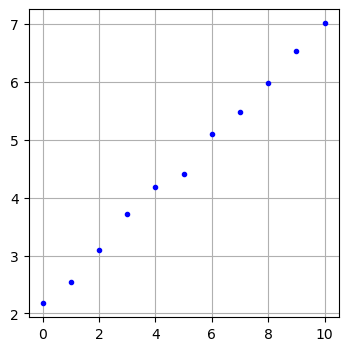

In [2]:
x = np.linspace(0,10,11)
A0 = 2
B0 = .5

y = A0 + B0*x + np.random.normal(size=len(x))*0.1 # add some noise to the data

plt.figure(figsize=(4,4))
plt.plot(x,y,'b.')
plt.grid()

You can see that the data has enough noise that it clearly doesn't fall on "the line" produced by the parameters, but it's "close".

Now let's form the model array, and get its SVD decomposition.

In [3]:
M = np.array([np.ones(len(x)),x]).T
M

array([[ 1.,  0.],
       [ 1.,  1.],
       [ 1.,  2.],
       [ 1.,  3.],
       [ 1.,  4.],
       [ 1.,  5.],
       [ 1.,  6.],
       [ 1.,  7.],
       [ 1.,  8.],
       [ 1.,  9.],
       [ 1., 10.]])

In [4]:
U, S, V = np.linalg.svd(M, full_matrices=False)
U.shape, S.shape, V.shape

((11, 2), (2,), (2, 2))

In [5]:
eps = 1
while 1+eps != 1:
    eps = eps/2
eps


1.1102230246251565e-16

In [6]:
U.dot(np.diag(S)).dot(V)

array([[ 1.00000000e+00, -3.24080221e-15],
       [ 1.00000000e+00,  1.00000000e+00],
       [ 1.00000000e+00,  2.00000000e+00],
       [ 1.00000000e+00,  3.00000000e+00],
       [ 1.00000000e+00,  4.00000000e+00],
       [ 1.00000000e+00,  5.00000000e+00],
       [ 1.00000000e+00,  6.00000000e+00],
       [ 1.00000000e+00,  7.00000000e+00],
       [ 1.00000000e+00,  8.00000000e+00],
       [ 1.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00,  1.00000000e+01]])

In [7]:
alpha = (V.T).dot(np.diag(1/S)).dot(U.T).dot(y)
alpha

array([2.14570305, 0.48453989])

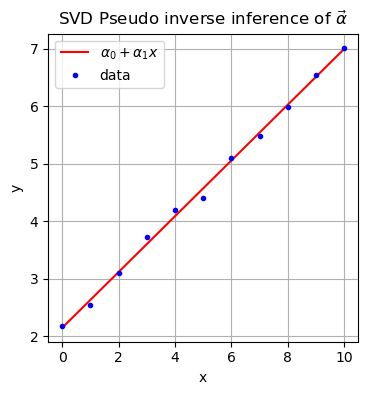

In [8]:
plt.figure(figsize=(4,4))
plt.title(r"SVD Pseudo inverse inference of $\vec{\alpha}$")
plt.plot(x,alpha[0] + alpha[1]*x,'r-',label=r"$\alpha_0 + \alpha_1 x$")
plt.plot(x,y,'b.',label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()

Excellent! This gives us a sort of "best fit" approximation based on the data. How do we get the uncertainty in the parameters? Read on! The next section discusses how to use `curve_fit` to find the "best fit" parameters to a general (even non-linear) function including the uncertainty in the parameters.

Power Law Distributions: Zipf's Law
=======================

(Note: Be sure to either download the data that goes with this notebook or uncomment/edit the lines below needed to get your own data before executing the code in this notebook.)

It turns out that "power law" distributions are ubitquitous in nature, see:

1 [http://arxiv.org/abs/cond-mat/0412004](http://arxiv.org/abs/cond-mat/0412004)

2 [https://arxiv.org/abs/1812.09662](https://arxiv.org/abs/1812.09662)

In the next feww cells of this notebook I measure the number of files of different sizes on my hard disk. Then I proceed to quantify (in the simples possible way) the distribution of file sizes in a certain range as a power law distribution.


In [9]:
def getFileSizes(folder, minsize=2000, maxsize=10**9):
    """
    return a list of file sizes in a folder
    """
    sizes = []
    for (path, dirs, files) in os.walk(folder):
        for file in files:
            try:
                filename = os.path.join(path, file)
                size=os.path.getsize(filename)
                if size>minsize and size<maxsize:
                    sizes.append(size)
            except OSError:
                pass
    return sizes

In [10]:
if 0: # set this to "1" to actaully collect data, but edit the paths to match your computer.
    minsize=10**4  # the minimum file size to consider
    maxsize=10**10 # the maximum file size to consider
    sizes = getFileSizes('/Users/steve/Desktop',minsize,maxsize) # <--- edit this to match some folder with a lot of files
    print(len(sizes), 'files between', minsize, 'and', maxsize)

In [11]:

if 0: # set this to "1" to write the file
    df=pd.DataFrame({'file_sizes':sizes})
    df.to_csv('myData.csv', sep=',')
else: # read the file
    df=pd.read_csv('myData.csv')
    df.head()
    sizes = df.file_sizes

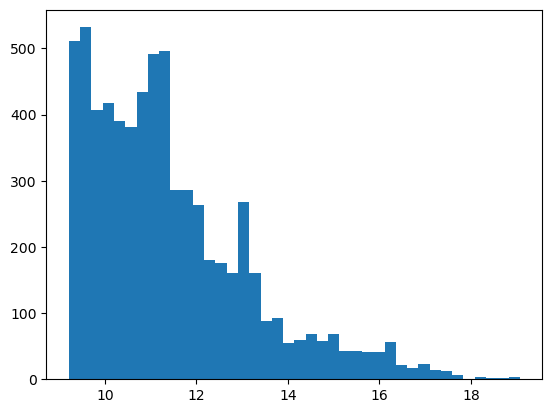

In [12]:
ns,bins,patches = plt.hist(np.log(np.array(sizes)+1),40)

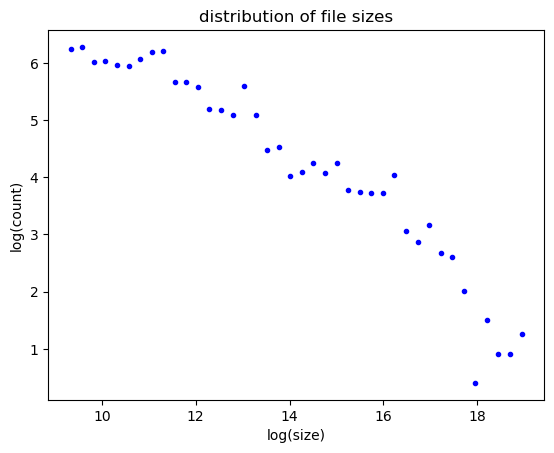

In [13]:
xvals=(bins[:-1]+bins[1:])/2.0
counts=ns+0.5
yvals=np.log(counts)
plt.title("distribution of file sizes")
plt.ylabel("log(count)")
plt.xlabel("log(size)")
plt.plot(xvals,yvals,'b.')

Using `curve_fit` to find the parameters and their uncertainties.
------------------------------------------------------------------

The cell below shows an example of using the `curve_fit` function to find the "best fit" parameters of the model. Then it uses a monte-carlo approach to find the uncertainties.The idea is to fabricate data that has the same statistics as our original data (do the degree that we know and/or care). Then we'll fit the fabricated data many times (1000 times in this case) and we'll look at the statistics of the fit parameters produced. From this we can tell how well our fit has done at narrowing down the parameters we computed. It turns out these uncertainties are also usually (but not always) equal to the square root of the diagonal elements of the covariance matrix returned by `curve_fit`. 


In [14]:
#
# Just to see same data fit using the non-linear scipy package "curve_fit":
#

def fLinear(x, m, b):
    return m*x + b

m0 = (yvals[-1]-yvals[0])/(xvals[-1]-xvals[0])  # estimate slope
b0 = yvals[0] - m0*xvals[0]                     # estimate intercept
sigma=1.0/np.sqrt(np.abs(counts))

popt, pcov = curve_fit(fLinear, xvals, yvals, p0=(m0, b0), sigma=sigma)

m=popt[0]          # slope
dm=np.sqrt(pcov[0,0]) # sqrt(variance(slope))
b=popt[1]          # int
db=np.sqrt(pcov[1,1]) # sqrt(variance(int))
ystar=fLinear(xvals, m, b)

print("m =", m, "+/-", dm)
print("b =", b, "+/-", db)


m = -0.40101296945888354 +/- 0.026750334278340417
b = 10.251110134355232 +/- 0.3095609206383513


In [15]:
#
# Another approach to estimate the uncertainty in the fit parameters is to use a Monte-Carlo method:
#

N=1000    # number of samples to take
mList=[]  # keep track of monte-carlo fit parameters
bList=[]

for i in range(N):
    """
    Generate mc data with the same statistical properties as the real data.
    Repeat the fit for each set, and record the parameters.
    """
    mcY = ystar + sigma*np.random.normal(size=len(xvals))  # generate fabricated data to fit
    mcpopt, mcpcov = curve_fit(fLinear, xvals, mcY, p0=(m,b), sigma=sigma)
    mList.append(mcpopt[0])  # store the fit paramters for the fab-data
    bList.append(mcpopt[1])

print("m =", np.mean(mList), "+/-", np.std(mList))
print("b =", np.mean(bList), "+/-", np.std(bList))

m = -0.40106884581153746 +/- 0.007036707416005283
b = 10.251204089980638 +/- 0.08095601883349351


(array([  3.,  17.,  45., 122., 229., 234., 188., 113.,  38.,  11.]),
 array([-0.4247365 , -0.42035282, -0.41596914, -0.41158545, -0.40720177,
        -0.40281809, -0.39843441, -0.39405073, -0.38966705, -0.38528337,
        -0.38089969]),
 <BarContainer object of 10 artists>)

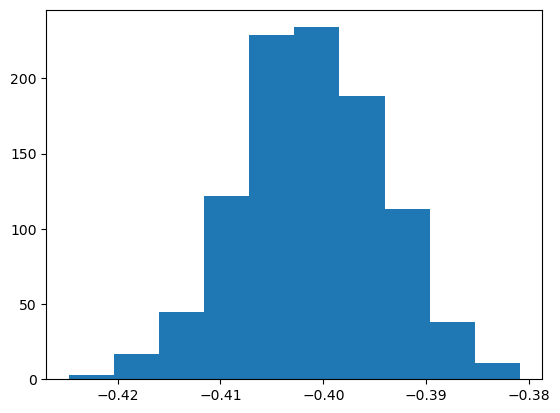

In [16]:
# check slope histogram

plt.hist(mList)

(array([ 13.,  47., 125., 200., 222., 217., 107.,  51.,  15.,   3.]),
 array([10.02728055, 10.07675944, 10.12623834, 10.17571723, 10.22519612,
        10.27467502, 10.32415391, 10.37363281, 10.4231117 , 10.4725906 ,
        10.52206949]),
 <BarContainer object of 10 artists>)

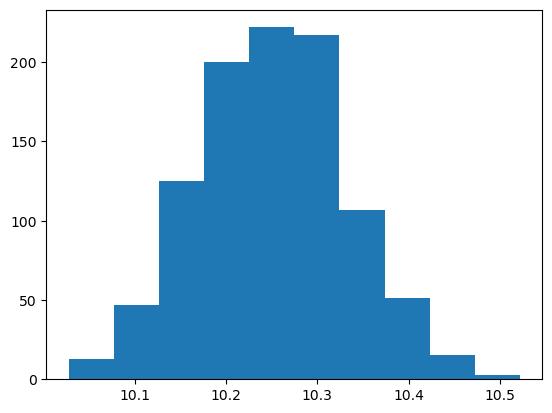

In [17]:
# check intercept histogram

plt.hist(bList)

Slope= -0.40101296945888354 +/- 0.007036707416005283 ( -0.4080496768748888 , -0.3939762620428783 )
Intercept= 10.251110134355232 +/- 0.08095601883349351 ( 9.94154921371688 , 10.332066153188725 )

Compare to cov-matrix for fun:
sqsrt(pcov[0,0]) (should be sigma m) 0.026750334278340417
sqrt(pcov[1,1]) (should be sigma b) 0.3095609206383513


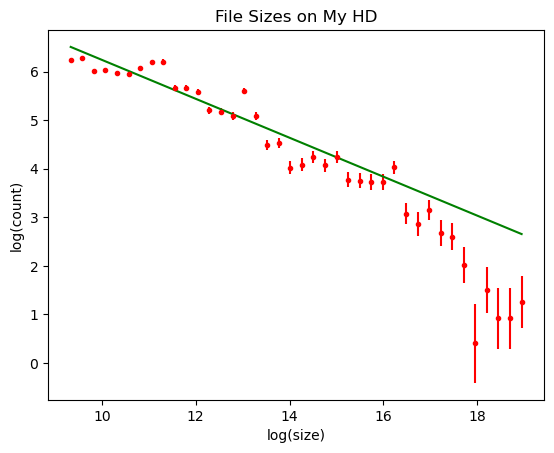

In [18]:
#
# Compute the statistics of the mc-results
#

marr=np.array(mList)
barr=np.array(bList)

mAvg = marr.mean()
bAvg = barr.mean()
sigM = marr.std()
sigB = barr.std()

plt.errorbar(xvals, yvals, sigma, fmt='r.') 
plt.title("File Sizes on My HD")
plt.ylabel("log(count)")
plt.xlabel("log(size)")
plt.plot(xvals,ystar, 'g-')
print("Slope=", m, '+/-', sigM, "(", m-sigM,",",m+sigM, ")")
print("Intercept=", b, '+/-', sigB, "(", b-db,",",b+sigB, ")")

print() # print a blank link
print("Compare to cov-matrix for fun:")
print("sqsrt(pcov[0,0]) (should be sigma m)", np.sqrt(pcov[0,0]))
print("sqrt(pcov[1,1]) (should be sigma b)", np.sqrt(pcov[1,1]))

#
# Note that in this case covariance matrix gives a more conservative estimate for the uncertainty.
# This is a clue that the data may not be perfectly described by the model, and that the uncertainties 
# may not be perfectly described by the sigma array. You can see this by looking at the variability of the data,
# and the extent of the error bars.
#

Project 7
=========

See this reference for other systems that exhibit power law behavior:

<http://arxiv.org/abs/cond-mat/0412004>

Or test your intuition and see if it's right. Many system exhibit this behavior!

Get some data, and test your idea. Use the matrix technique to do the fitting.

Matrix Approach
--------------------

# WARNING: THE REST OF THIS NOTEBOOK IS OPTIONAL. YOU DO NOT NEED TO READ FURTHER UNLESS YOU ARE CURIOUS/INTERSTED IN THE INNER MACHINERY OF CURVE FITTING

The remainder of this notebook details another approach to parameter estimation
using matrices. If you're interested, you're welcome to use this approach to 
fit your data. It has the (minor) advantage that there are no "black boxes"
like `curve_fit`. The underlying mathematics is open for your inspection! However
it's also pretty mathematically "heavy" so, please use `curve_fit` if you prefer.


Fitting Data with Matrices 
===========================

We can see that we have something that looks like it might be a power law. How can we tell? We'll use "linear least squares" analysis.

When fitting some experimental data to a model, there are typically
a set of paramters $(\alpha_1, \alpha_2, \ldots, \alpha_n)$ that
need to be found so that the function $\chi^2$ is a minimum. 
We can think of the paramters as an n-vector called $\alpha$. The
data consist of a set of paired numbers $(x_i, y_i)$ and we can
define $\chi^2$ as 

\begin{equation}
\chi^2 = \sum_{i=1}^{m} {(y_i - y^\star(x_i,\alpha))^2\over \sigma_i^2},
\end{equation}

where $\sigma_i$ is the uncertainty in $y_i$, and $y^\star$ is the
model value corresponding to $x_i$ (and the value of the parameters
$\alpha$). If the model $y^\star(x,\vec\alpha)$ is *linear* then we
can write $y^\star$ as:

\begin{equation}
y^\star (x) = \alpha_1 X_1(x)+\alpha_2 X_2(x)+\ldots+\alpha_n X_n(x).
\end{equation}

or

\begin{equation}
y^\star(x) = \sum_{j=1}^{n} \alpha_j X_j(x),
\end{equation}

where the $X_j$ are a set of functions that are to be superposed
with coefficients $\alpha_j$ to form the model. A common example
of this would be a straight line fit $y^\star(x) = mx+b$ where the
functions are $x$ and 1 for the paramters $m$ and $b$ respectively.

Notice that, since the $x$'s are at fixed measured values, this whole thing can be 
cast into a single matrix equation. If we define the following $M$ matrix:

\begin{equation}
M_{ij} = X_j(x_i)
\end{equation}

and if we think of $y^\star$ as an $m$-vector of model 
values evaluated at the $m$ data points $x_i$ and $y$ as an 
experimental $m$-vector $y$, then the model vector
can be evaluated by matrix multiplication as:

\begin{equation}
y^\star = M \alpha
\end{equation}

and the difference vector between the model and the data becomes simply

\begin{equation}
y - y^\star = y - M\alpha
\end{equation}

Finally we can write $\chi^2$ as 

\begin{equation}
\chi^2 = (y - M\alpha)^T S (y - M\alpha) \,\,\,\,\,\,\,\,(1)
\end{equation}

where $S$ is a diagonal matrix of $1/\sigma_i^2$ and
the $T$ on the left side means "transpose".

Now it is a simple matter to find the values of the paramters that
minimize $\chi^2$. We require that $\nabla_{\alpha}\chi^2 = 0$. 
If you play around with this you can convince yourself that this means:

\begin{equation}
M^T S(y - M\alpha) = 0
\end{equation}

and therefore:

\begin{equation}
\alpha = (M^T SM)^{-1}M^T S y.  \,\,\,\,\,\,\,\,(2)
\end{equation}

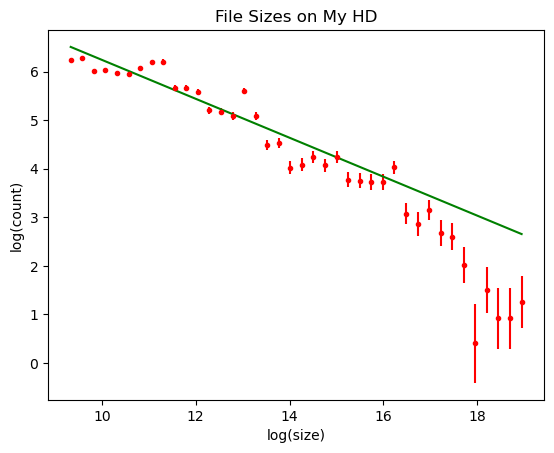

In [19]:
#
# define the function values (these are the columns of the "M" matrix
#
# generate arrays that contain "functions" of x that are combined to form the model
#

def doFit(funcs, xvals, yvals, sigma):
    """
    doFit uses matrices to solve for the linear least squares 
    fit parameters based on the list of 'funcs', and the x-y values
    and their corresponding uncertainties (sigma).
    
    returns the array of model parameters
    """
    #
    # define the S matrix in terms of uncertainties
    #
    
    S=np.diag((1.0/sigma)**2)
    
    #
    # define the model matrix
    #
    
    M = np.array(funcs).T
    MtM = M.T.dot(S.dot(M))
    MtMInv = np.linalg.inv(MtM)
    MtY = M.T.dot(S.dot(yvals))
    alpha = MtMInv.dot(MtY)      # see eq 2 above.
    
    #
    # solve for the parameters, and return
    #
    ystar = M.dot(alpha)
    
    return (alpha, ystar, MtMInv)

fx1 = np.ones(len(xvals))   # X_1(x) = 1
fx2 = xvals              # X_2(x) = x

sigma=1.0/np.sqrt(np.abs(counts))

alpha, ystar, fcov = doFit([fx1, fx2], xvals, yvals, sigma)

mFit = alpha[1]
bFit = alpha[0]

plt.errorbar(xvals, yvals, sigma, fmt='r.') 
plt.title("File Sizes on My HD")
plt.ylabel("log(count)")
plt.xlabel("log(size)")
plt.plot(xvals,ystar, 'g-')


In [20]:
#
# Now do monte-carlo data fabrication and fit analysis
#

N=1000    # number of samples to take
mList=[]  # keep track of monte-carlo fit parameters
bList=[]

for i in range(N):
    """
    Generate mc data with the same statistical properties as the real data.
    Repeat the fit for each set, and record the parameters.
    """
    mcY = ystar + sigma*np.random.normal(size=len(xvals))
    mcAlpha,mcYstar,mccov = doFit([fx1,fx2],xvals,mcY,sigma)   # repeatedly fit mc data
    mList.append(mcAlpha[1])
    bList.append(mcAlpha[0])
    
#
# Compute the statistics of the mc-results
#

marr=np.array(mList)
barr=np.array(bList)

mAvg = marr.sum()/N
bAvg = barr.sum()/N
delM = marr-mAvg
delB = barr-bAvg
sigM = np.sqrt((delM*delM).sum()/(N-1))  # sigM is the std-deviation of the m values
sigB = np.sqrt((delB*delB).sum()/(N-1))  # sigB is the std-deviation of the b values

#
# plot the fit
#
print("Slope=", mFit, '+/-', sigM, "(", mFit - sigM,",",mFit + sigM, ")")
print("Intercept=", bFit, '+/-', sigB, "(", bFit - sigB,",",bFit + sigB, ")")

#
# Just for fun print out the diagonals of the covariance matrix.
#
print # print a blank link
print("Compare to cov-matrix for fun:")
print("sqsrt(cov[1,1]) (should be sigma m)", np.sqrt(fcov[1,1]))
print("sqrt(cov[0,0]) (should be sigma b)", np.sqrt(fcov[0,0]))


Slope= -0.4010129721038747 +/- 0.006964568138558088 ( -0.4079775402424328 , -0.3940484039653166 )
Intercept= 10.251110164592228 +/- 0.08024823635230328 ( 10.170861928239924 , 10.331358400944533 )
Compare to cov-matrix for fun:
sqsrt(cov[1,1]) (should be sigma m) 0.0069199376080289685
sqrt(cov[0,0]) (should be sigma b) 0.08007908396499795


m average: -0.4009257150208895
m sigma: 0.006964568138558088


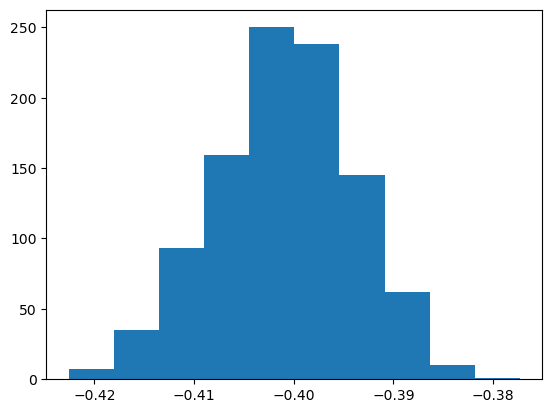

In [21]:
plt.hist(marr) # look at the variation in "m" values
print("m average:", mAvg)
print("m sigma:",sigM)

b average: 10.250261837641116
b sigma: 0.08024823635230328


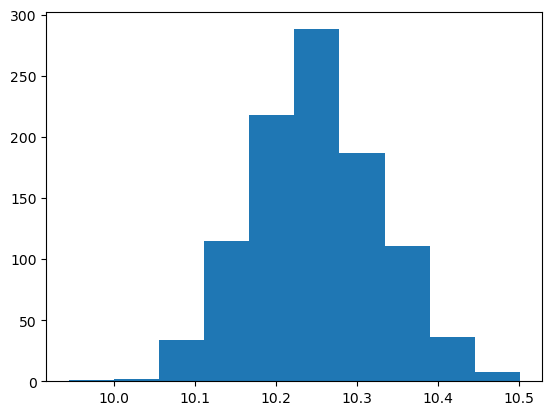

In [22]:
plt.hist(barr)  # look at the variation in "b" values
print("b average:", bAvg)
print("b sigma:",sigB)

Chi-Squared Goodness of Fit (Optional)
=======================================

Once we have a fit, a natural question is: *how good is it?* The $\chi^2$ statistic gives a quantitative answer.

Recall the definition:

$$\chi^2 = \sum_{i=1}^{m} \frac{(y_i - y^\star(x_i))^2}{\sigma_i^2}$$

If the model is correct and the $\sigma_i$ accurately describe the measurement uncertainties, then $\chi^2$ is a random variable that follows a **chi-squared probability distribution** with $\nu = m - n$ **degrees of freedom**, where $m$ is the number of data points and $n$ is the number of free parameters.

The **reduced chi-squared** $\tilde{\chi}^2 = \chi^2 / \nu$ is a convenient summary:

| $\tilde{\chi}^2$ | Interpretation |
|---|---|
| $\approx 1$ | Good fit — residuals are consistent with the stated $\sigma_i$ |
| $\gg 1$ | Poor fit, or $\sigma_i$ are underestimated |
| $\ll 1$ | $\sigma_i$ are overestimated, or the model has too many parameters |

We can also compute a **p-value**: the probability of observing a $\chi^2$ *this large or larger* purely by chance if the model is actually correct. A small p-value (e.g. $< 0.05$) is evidence that the model or the uncertainties need revisiting.

In [23]:
from scipy.stats import chi2 as chi2dist

# ystar and sigma are already defined from the matrix fit above.
# yvals are the log(counts) data points.
# We fit a 2-parameter model (slope + intercept), so dof = N_data - 2.

residuals = yvals - ystar
chi2_val  = np.sum((residuals / sigma)**2)

n_params = 2                        # slope and intercept
dof      = len(xvals) - n_params    # degrees of freedom
chi2_red = chi2_val / dof           # reduced chi-squared

print(f"chi^2          = {chi2_val:.2f}")
print(f"degrees of freedom (dof) = {dof}")
print(f"reduced chi^2  = chi^2 / dof = {chi2_red:.2f}")

# p-value: P(chi2 >= observed | model is correct)
# scipy's "survival function" sf(x) = 1 - cdf(x) gives this directly.
p_value = chi2dist.sf(chi2_val, df=dof)
print(f"p-value        = {p_value:.4f}")

if p_value > 0.05:
    print("\np > 0.05 — no strong evidence against the model.")
    print("The residuals are plausibly consistent with the stated uncertainties.")
else:
    print("\np < 0.05 — the fit may be poor, or the sigma_i may be mis-estimated.")
    print("Consider checking whether the model or the error bars need revision.")

chi^2          = 567.86
degrees of freedom (dof) = 38
reduced chi^2  = chi^2 / dof = 14.94
p-value        = 0.0000

p < 0.05 — the fit may be poor, or the sigma_i may be mis-estimated.
Consider checking whether the model or the error bars need revision.


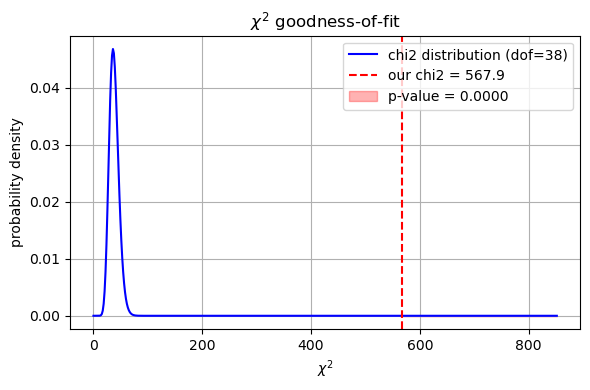

In [24]:
# Plot the chi-squared probability distribution and show where our value falls.

chi2_range = np.linspace(0, max(3 * dof, chi2_val * 1.5), 500)
pdf = chi2dist.pdf(chi2_range, df=dof)

plt.figure(figsize=(6, 4))
plt.plot(chi2_range, pdf, 'b-', label=f'chi2 distribution (dof={dof})')
plt.axvline(chi2_val, color='r', linestyle='--', label=f'our chi2 = {chi2_val:.1f}')
plt.fill_between(chi2_range, pdf,
                 where=(chi2_range >= chi2_val),
                 alpha=0.3, color='r', label=f'p-value = {p_value:.4f}')
plt.xlabel(r'$\chi^2$')
plt.ylabel('probability density')
plt.title(r'$\chi^2$ goodness-of-fit')
plt.legend()
plt.grid()
plt.tight_layout()

### Interpreting the result

You should find a large reduced $\tilde{\chi}^2$ (much greater than 1) and a very small p-value — even though the slope and intercept are determined with quite small uncertainties.

This reveals an important distinction:

> **Small parameter uncertainties do not mean a good fit.**

The parameter uncertainties tell us *how precisely* the data constrain the slope and intercept *of this model*. The chi-squared tells us whether *this model is adequate* — i.e., whether the residuals are consistent with the measurement noise.

Here, the residuals are systematically larger than the $\sigma_i$ predict. That is a sign that the straight-line power-law model is an approximation: it captures the overall trend, but the actual file-size distribution has structure the model cannot account for. The chi-squared catches what the parameter uncertainties miss.